In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# **Getting Data Insights**

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [7]:
df[cols] = df[cols].replace({'No phone service':'No',
                             'No internet service' : 'No'})

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df['Churn'].value_counts()/df.shape[0] * 100

,count
Churn,
No,73.463013
Yes,26.536987


In [14]:
df['PaymentMethod'] = df['PaymentMethod'].replace({'Bank transfer (automatic)':'Bank transfer',
                                                   'Credit card (automatic)':'Credit card'})

In [15]:
df = df.drop('customerID',axis=1)

In [16]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:'No',
                                                   1:'Yes'}).astype('object')


# **Data Analysis using visualization**


<Axes: xlabel='PaymentMethod', ylabel='count'>

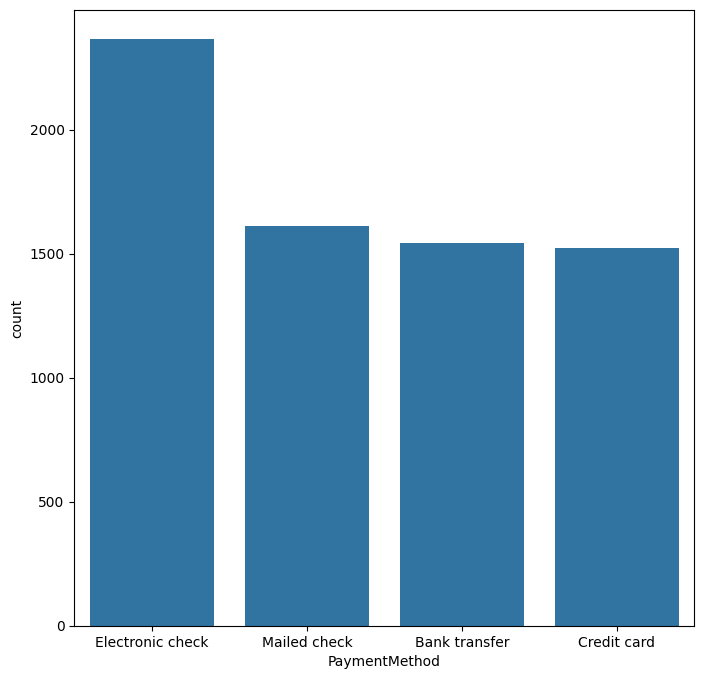

In [19]:
plt.figure(figsize=[8,8])
sns.countplot(x='PaymentMethod',data=df)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

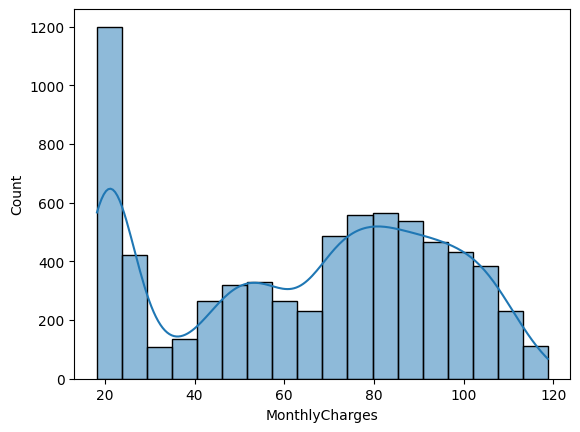

In [20]:
sns.histplot(x='MonthlyCharges',data=df,kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='InternetService'>

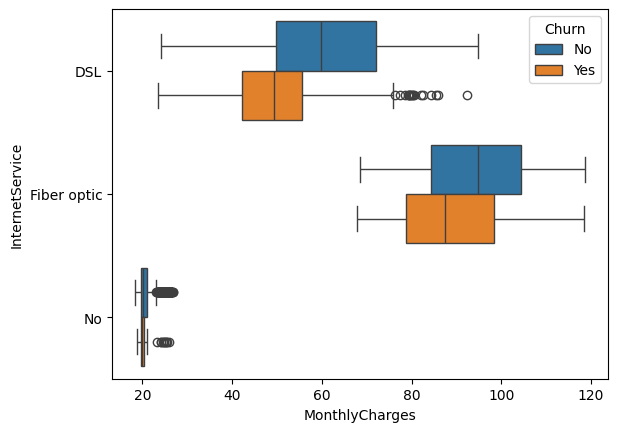

In [21]:
sns.boxplot(x='MonthlyCharges',y='InternetService',data=df,hue='Churn')

In [22]:

print(df['MonthlyCharges'].skew())

-0.22052443394398033


In [24]:
print(df['TotalCharges'].skew())

0.963234654832277


<Axes: xlabel='TotalCharges', ylabel='Count'>

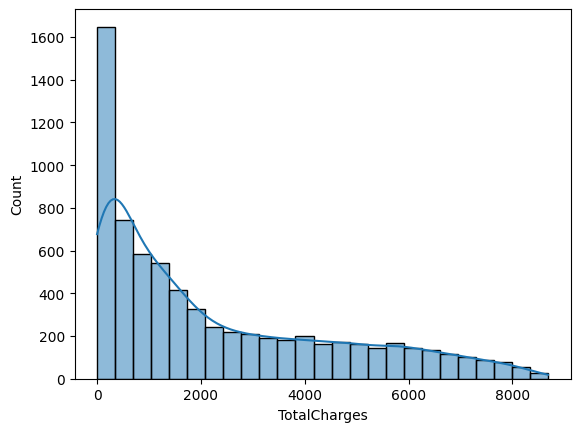

In [25]:
sns.histplot(x='TotalCharges',data=df,kde=True)

<Axes: xlabel='Churn', ylabel='count'>

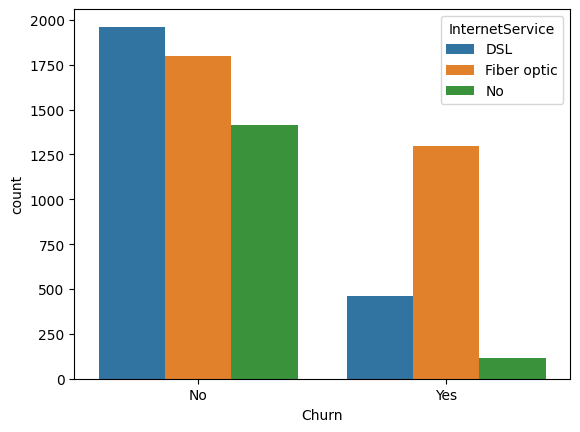

In [26]:
sns.countplot(hue='InternetService',x='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

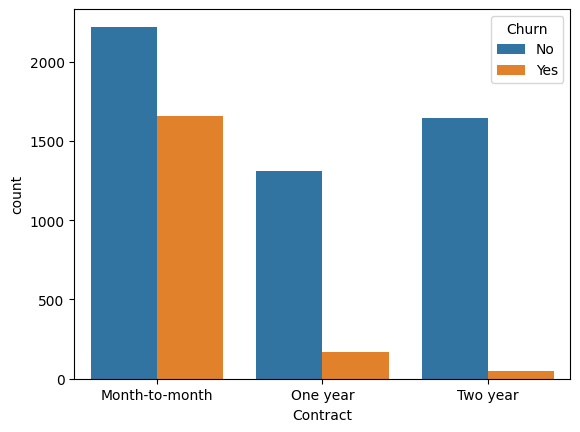

In [27]:
sns.countplot(x='Contract',data=df,hue='Churn')

<Axes: xlabel='Churn', ylabel='tenure'>

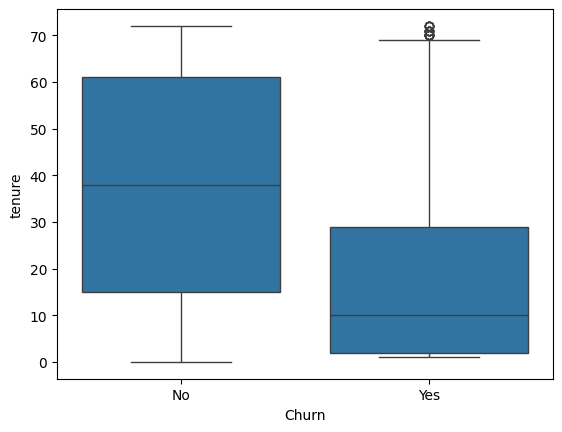

In [28]:
sns.boxplot(x='Churn',y='tenure',data=df)

In [30]:
X = df.drop('Churn',axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [31]:
df.select_dtypes(include='object').columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

# **Feature Engineering and Splitting the data**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService','MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling', 'PaymentMethod']
num_cols = ['tenure','MonthlyCharges','TotalCharges']
ord_col = ['Contract']

nominal_pipeline = Pipeline(steps=[
    ('encode' , OneHotEncoder(drop='first',handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('scale' , StandardScaler())
])

ord_pipeline = Pipeline(steps=[
    ('ordinal',OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
])

preprocessor = ColumnTransformer(transformers=[
    ('ordinal',ord_pipeline,ord_col),
    ('scaler',num_pipeline,num_cols),
    ('nominal',nominal_pipeline,cat_cols)
])

# **Model Building and Evaluation**

Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.model_selection import GridSearchCV

logistic_pipeline = Pipeline(steps=[
    ('pre-processing',preprocessor),
    ('logistic',LogisticRegression(C= 2, class_weight= 'balanced', l1_ratio= 0.5, penalty='l1',solver='saga'))
])

logistic_pipeline.fit(X_train,y_train)
y_pred_logistic = logistic_pipeline.predict(X_test)

y_pred_train = logistic_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_logistic))
print(f'recall : {recall_score(y_test, y_pred_logistic)}')
print(confusion_matrix(y_test, y_pred_logistic))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_pred_train))
print(f'recall : {recall_score(y_train, y_pred_train)}')
print(confusion_matrix(y_train, y_pred_train))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1539
           1       0.53      0.83      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.82      0.76      0.77      2113

recall : 0.8344947735191638
[[1118  421]
 [  95  479]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      3635
           1       0.50      0.80      0.62      1295

    accuracy                           0.74      4930
   macro avg       0.71      0.76      0.71      4930
weighted avg       0.80      0.74      0.75      4930

recall : 0.7992277992277992
[[2606 1029]
 [ 260 1035]]


In [40]:
from sklearn.model_selection import GridSearchCV
lr_param_grid = {
    'logistic__penalty': ['l1', 'l2', 'elasticnet'],
    'logistic__C': [1, 2, 3, 4, 5],
    'logistic__solver': ['saga'],
    'logistic__l1_ratio': [0.5],
    'logistic__class_weight': ['balanced']
}

lr_search = GridSearchCV(logistic_pipeline, lr_param_grid, scoring='recall', n_jobs=-1, cv=5)
lr_search.fit(X_train, y_train)
print(lr_search.best_params_)

{'logistic__C': 2, 'logistic__class_weight': 'balanced', 'logistic__l1_ratio': 0.5, 'logistic__penalty': 'l1', 'logistic__solver': 'saga'}


In [42]:
lr_search.best_estimator_

Pipeline(steps=[('pre-processing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                               'One '
                                                                                               'year',
                                                                                               'Two '
                                                                                               'year']]))]),
                                                  ['Contract']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('nominal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(drop='f...
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('logistic',
                 LogisticRegression(C=2, class_weight='balanced', l1_ratio=0.5,
                                    penalty='l1', solver='saga'))])

RandomForest

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score

rfc_pipeline = Pipeline(steps=[
    ('pre-processing',preprocessor),
    ('rfc',RandomForestClassifier(class_weight = 'balanced', max_depth = 2, min_samples_split = 2, n_estimators = 50))
])

rfc_pipeline.fit(X_train,y_train)
y_pred_rfc = rfc_pipeline.predict(X_test)

y_pred_train_rfc = rfc_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_rfc))
print(f'recall : {recall_score(y_test, y_pred_rfc)}')
print(confusion_matrix(y_test, y_pred_rfc))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_pred_train_rfc))
print(f'recall : {recall_score(y_train, y_pred_train_rfc)}')
print(confusion_matrix(y_train, y_pred_train_rfc))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1539
           1       0.52      0.85      0.65       574

    accuracy                           0.75      2113
   macro avg       0.72      0.78      0.73      2113
weighted avg       0.82      0.75      0.76      2113

recall : 0.8466898954703833
[[1095  444]
 [  88  486]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.91      0.71      0.79      3635
           1       0.49      0.80      0.61      1295

    accuracy                           0.73      4930
   macro avg       0.70      0.75      0.70      4930
weighted avg       0.80      0.73      0.75      4930

recall : 0.7984555984555984
[[2564 1071]
 [ 261 1034]]


In [45]:
rf_param_grid = {
    'rfc__n_estimators' : [100,200,50],
    'rfc__max_depth' : [2,5,10],
    'rfc__class_weight' : ['balanced'],
    'rfc__min_samples_split' : [2,5,12]
}

rfc_search = GridSearchCV(rfc_pipeline,rf_param_grid,scoring='recall',cv=5,n_jobs=-1)
rfc_search.fit(X_train,y_train)
print(rfc_search.best_params_)


{'rfc__class_weight': 'balanced', 'rfc__max_depth': 2, 'rfc__min_samples_split': 2, 'rfc__n_estimators': 50}


In [48]:
rfc_search.best_estimator_

Pipeline(steps=[('pre-processing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                               'One '
                                                                                               'year',
                                                                                               'Two '
                                                                                               'year']]))]),
                                                  ['Contract']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('nominal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(drop='f...',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('rfc',
                 RandomForestClassifier(class_weight='balanced', max_depth=2,
                                        n_estimators=50))])

KNN Classifier

In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('knn',KNeighborsClassifier(algorithm = 'ball_tree', n_neighbors = 5, weights = 'uniform'))
])

knn_pipeline.fit(X_train,y_train)
y_pred_knn = knn_pipeline.predict(X_test)
y_train_knn = knn_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_knn))
print(f'recall : {recall_score(y_test, y_pred_knn)}')
print(confusion_matrix(y_test, y_pred_knn))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_train_knn))
print(f'recall : {recall_score(y_train, y_train_knn)}')
print(confusion_matrix(y_train, y_train_knn))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1539
           1       0.58      0.53      0.56       574

    accuracy                           0.77      2113
   macro avg       0.71      0.70      0.70      2113
weighted avg       0.76      0.77      0.77      2113

recall : 0.5331010452961672
[[1320  219]
 [ 268  306]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3635
           1       0.71      0.64      0.67      1295

    accuracy                           0.84      4930
   macro avg       0.79      0.77      0.78      4930
weighted avg       0.83      0.84      0.83      4930

recall : 0.637065637065637
[[3297  338]
 [ 470  825]]


In [50]:
from sklearn.model_selection import GridSearchCV
knn_param_grid = {
    'knn__n_neighbors' : [3,5,10],
    'knn__weights' : ['uniform','distance'],
    'knn__algorithm' : ['ball_tree']
}

knn_search = GridSearchCV(knn_pipeline,knn_param_grid,n_jobs=-1,scoring='recall',cv=5)
knn_search.fit(X_train,y_train)
print(knn_search.best_params_)

{'knn__algorithm': 'ball_tree', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}


XgBoost

In [51]:
!pip install xgboost

In [63]:
from xgboost import XGBClassifier

spw = (y_train==0).sum() / (y_train==1).sum()

xg_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('xgb',XGBClassifier(colsample_bytree =  0.9, learning_rate = 0.1, max_depth = 3, n_estimators = 100, subsample = 0.7,scale_pos_weight=spw,eval_metric='logloss'))
])



xg_pipeline.fit(X_train,y_train)
y_pred_xg = xg_pipeline.predict(X_test)
y_train_xg = xg_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_xg))
print(f'recall : {recall_score(y_test, y_pred_xg)}')
print(confusion_matrix(y_test, y_pred_xg))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_train_xg))
print(f'recall : {recall_score(y_train, y_train_xg)}')
print(confusion_matrix(y_train, y_train_xg))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1539
           1       0.53      0.84      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.82      0.76      0.77      2113

recall : 0.8397212543554007
[[1115  424]
 [  92  482]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.93      0.74      0.82      3635
           1       0.53      0.85      0.65      1295

    accuracy                           0.77      4930
   macro avg       0.73      0.79      0.74      4930
weighted avg       0.83      0.77      0.78      4930

recall : 0.8455598455598455
[[2680  955]
 [ 200 1095]]


In [71]:
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.9],
    'xgb__colsample_bytree': [0.7, 0.9],
    'xgb__scale_pos_weight' : [spw],
    'xgb__eval_metric' : ['logloss']

}

xgb_search = GridSearchCV(xg_pipeline, xgb_param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=1)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'xgb__colsample_bytree': 0.9, 'xgb__eval_metric': 'logloss', 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__scale_pos_weight': np.float64(2.806949806949807), 'xgb__subsample': 0.7}


In [72]:
xgb_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                               'One '
                                                                                               'year',
                                                                                               'Two '
                                                                                               'year']]))]),
                                                  ['Contract']),
                                                 ('scaler',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('nominal',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(drop='fi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

**ROC**-AUC

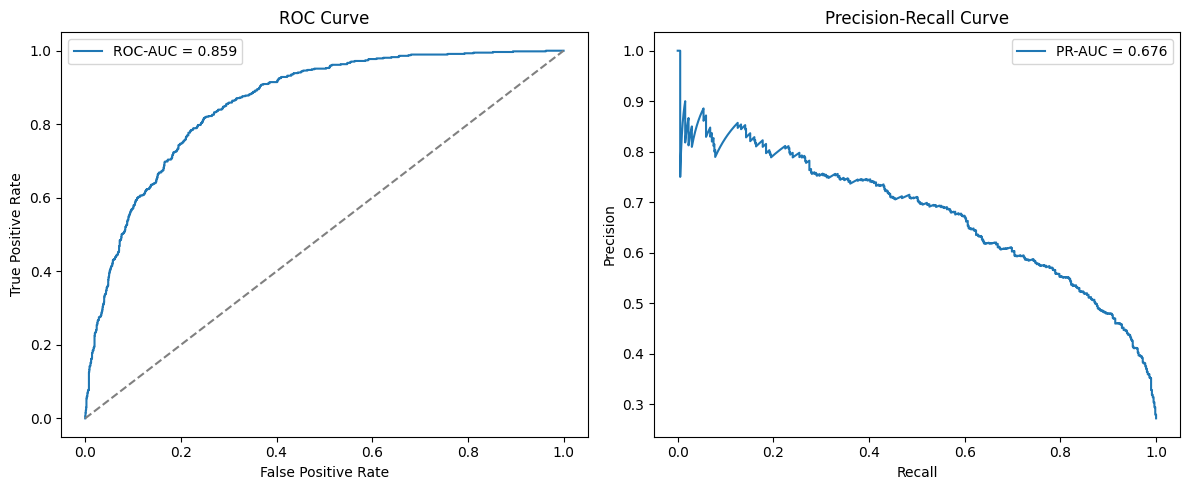

ROC-AUC: 0.859
PR-AUC: 0.676


In [64]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

y_proba = lr_search.best_estimator_.predict_proba(X_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

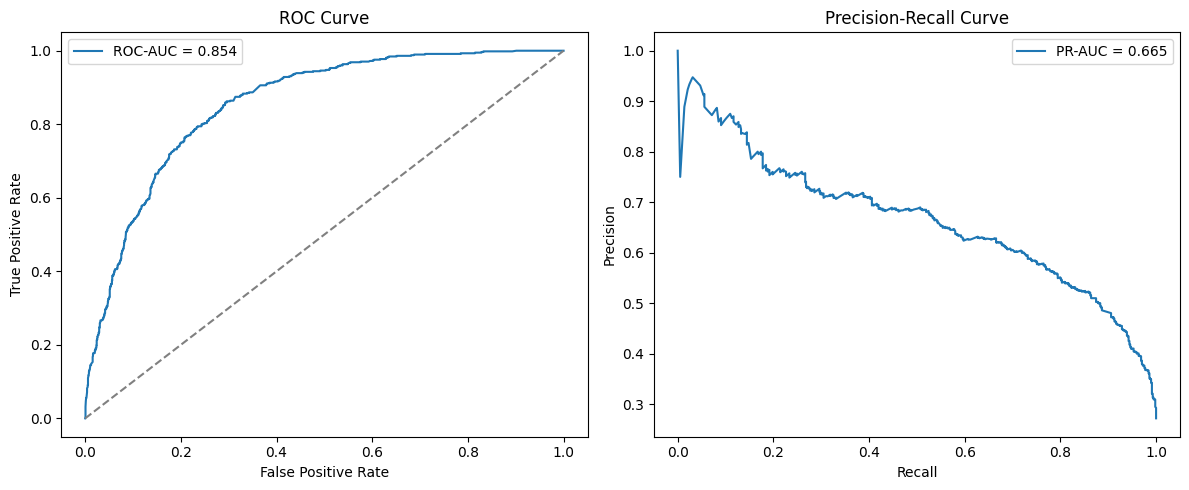

ROC-AUC: 0.854
PR-AUC: 0.665


In [65]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

y_proba = rfc_search.best_estimator_.predict_proba(X_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

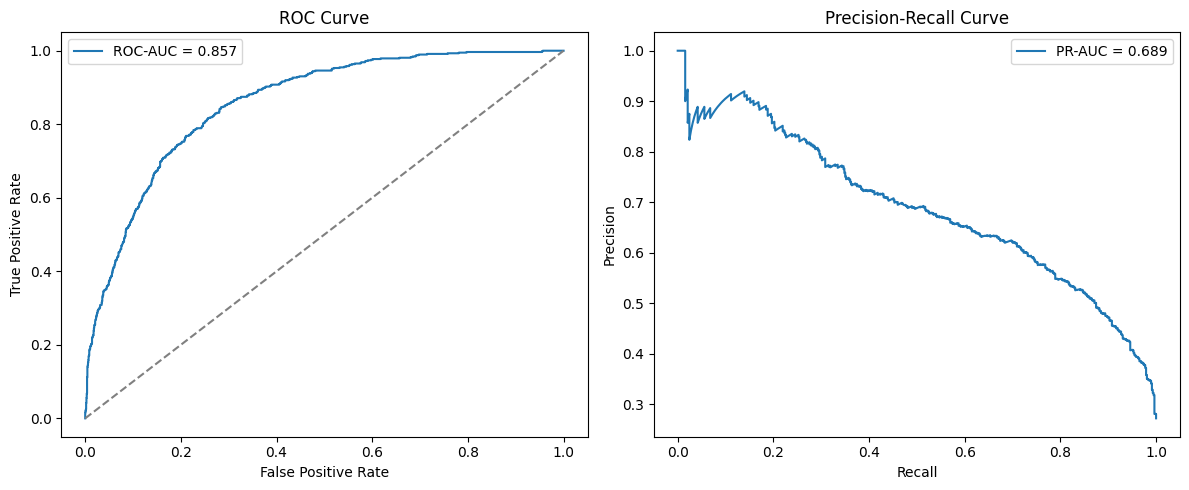

ROC-AUC: 0.857
PR-AUC: 0.689


In [66]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

y_proba = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

In [73]:
import joblib
joblib.dump(xgb_search.best_estimator_,'Customer_churn.pkl')

['Customer_churn.pkl']